<a href="https://colab.research.google.com/github/smosharof/Resume.Walkthrough/blob/main/Credit_Card_Fraud_Detection_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest

# 1. Load the dataset
#df = pd.read_csv("synthetic_fraud_dataset.csv")



# Download the dataset
path = kagglehub.dataset_download("samayashar/fraud-detection-transactions-dataset")

# Get the list of files in the directory
files = os.listdir(path)

# Assuming the CSV file is the only file or one of the CSV files
csv_files = [file for file in files if file.endswith('.csv')]

if len(csv_files) > 0:
    csv_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_path)
else:
    print("No CSV files found in the downloaded dataset.")
    df = None

if df is not None:
    print("Dataset loaded successfully.")
    print(df.head())  # Display the first few rows
    print(df.info())  # Display dataset information
else:
    print("Dataset loading failed. 'df' not created.")

Dataset loaded successfully.
  Transaction_ID    User_ID  Transaction_Amount Transaction_Type  \
0      TXN_33553  USER_1834               39.79              POS   
1       TXN_9427  USER_7875                1.19    Bank Transfer   
2        TXN_199  USER_2734               28.96           Online   
3      TXN_12447  USER_2617              254.32   ATM Withdrawal   
4      TXN_39489  USER_2014               31.28              POS   

             Timestamp  Account_Balance Device_Type  Location  \
0  2023-08-14 19:30:00         93213.17      Laptop    Sydney   
1  2023-06-07 04:01:00         75725.25      Mobile  New York   
2  2023-06-20 15:25:00          1588.96      Tablet    Mumbai   
3  2023-12-07 00:31:00         76807.20      Tablet  New York   
4  2023-11-11 23:44:00         92354.66      Mobile    Mumbai   

  Merchant_Category  IP_Address_Flag  ...  Daily_Transaction_Count  \
0            Travel                0  ...                        7   
1          Clothing            

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50

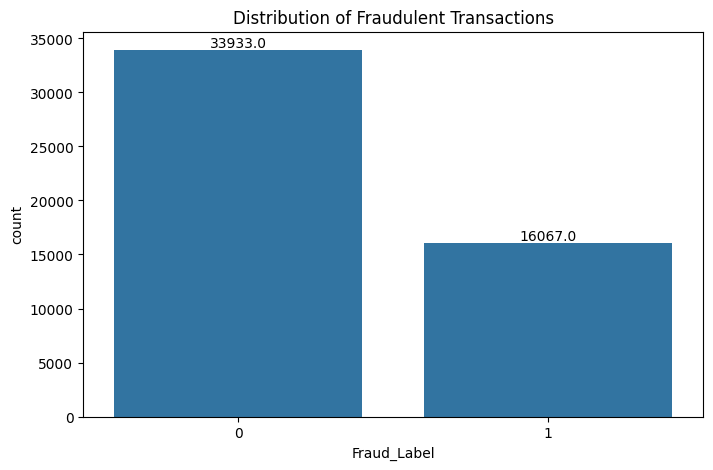

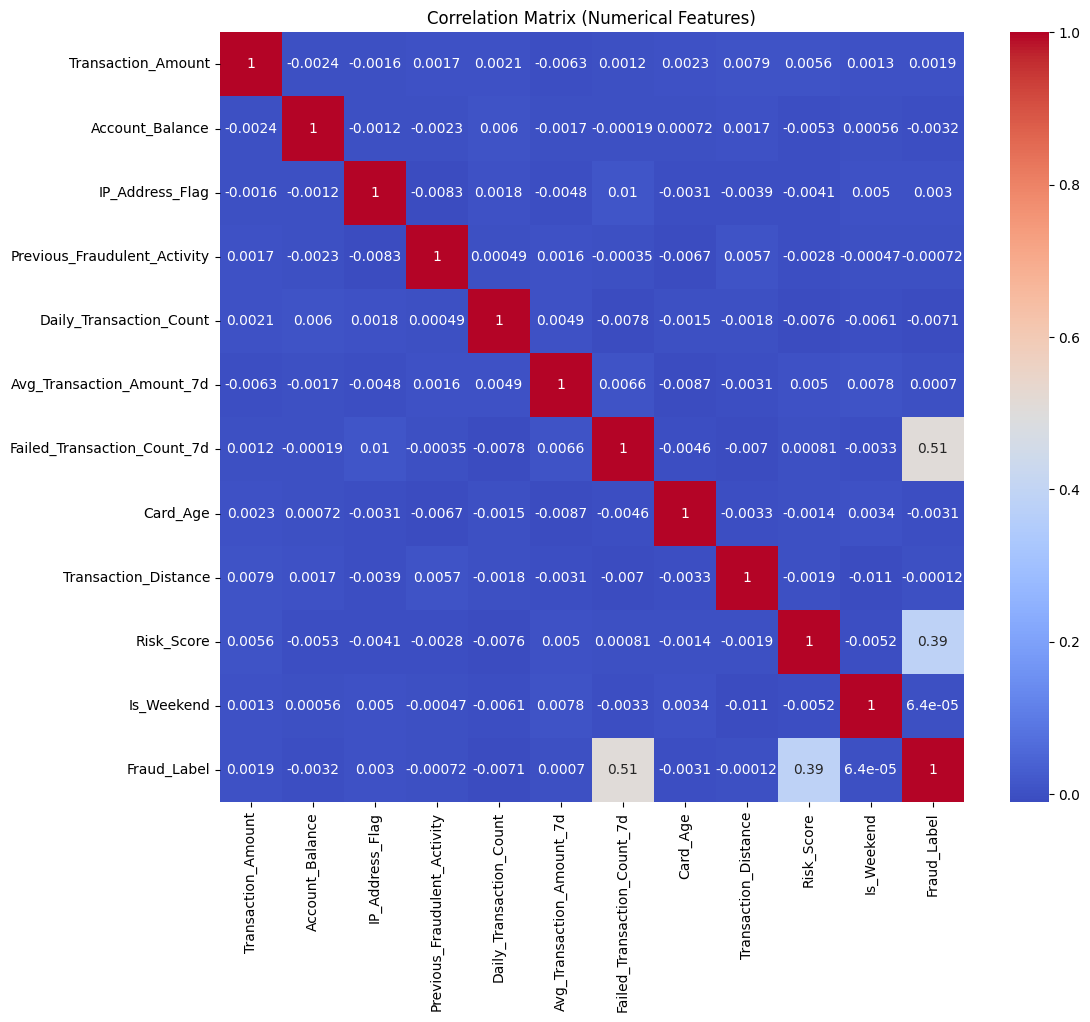

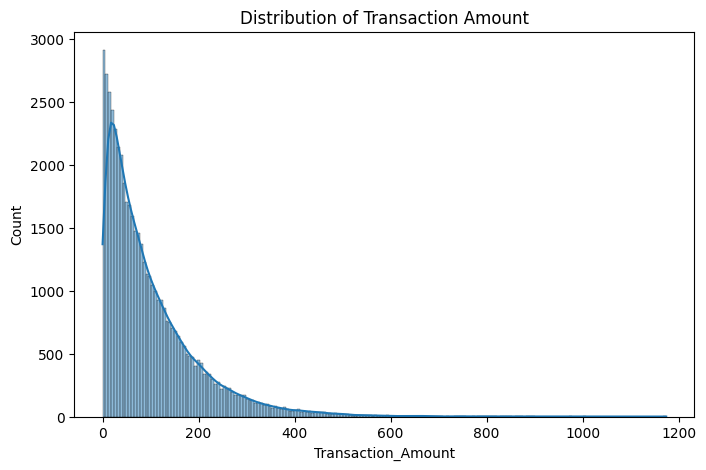

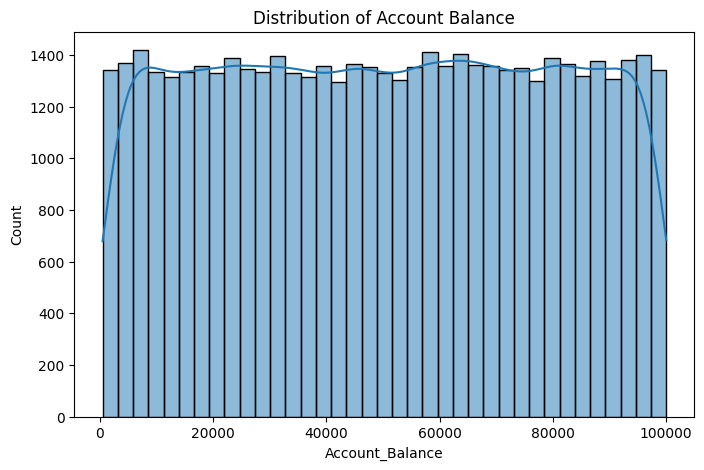

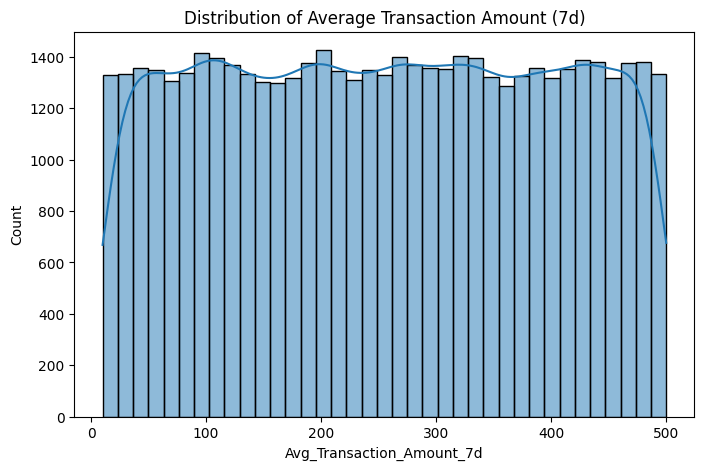

In [9]:
# 2. Exploratory Data Analysis (EDA)
def perform_eda(df):
    """Performs exploratory data analysis on the dataset."""

    print("--- Dataset Information ---")
    print(df.info())

    print("\n--- Summary Statistics ---")
    print(df.describe())

    print("\n--- Missing Values ---")
    print(df.isnull().sum())

    # Visualize class distribution
    if 'Fraud_Label' in df.columns:  # Use the correct column name
        plt.figure(figsize=(8, 5))
        ax = sns.countplot(x='Fraud_Label', data=df)
        plt.title('Distribution of Fraudulent Transactions')

        # Add annotations to the bars
        for p in ax.patches:
            ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom', fontsize=10)

        plt.show()
    else:
        print("Warning: 'Fraud_Label' column not found. Skipping class distribution visualization.")

    # Visualize correlations (only for numerical columns)
    numerical_df = df.select_dtypes(include=np.number)  # Select only numeric columns
    plt.figure(figsize=(12, 10))
    sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm')
    plt.title('Correlation Matrix (Numerical Features)')
    plt.show()

    # Visualize feature distributions (example with a few numerical features)
    if 'Transaction_Amount' in df.columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(df['Transaction_Amount'], kde=True)
        plt.title('Distribution of Transaction Amount')
        plt.show()

    if 'Account_Balance' in df.columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(df['Account_Balance'], kde=True)
        plt.title('Distribution of Account Balance')
        plt.show()

    if 'Avg_Transaction_Amount_7d' in df.columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(df['Avg_Transaction_Amount_7d'], kde=True)
        plt.title('Distribution of Average Transaction Amount (7d)')
        plt.show()

    # Add more visualizations as needed

perform_eda(df)

In [10]:
# 3. Feature Selection/Engineering
# Identify features relevant for fraud detection.  This is highly dependent on the dataset.
# Here's a basic example; you'll likely need to adapt this.
# After EDA, you'll have a better idea of which columns are present and relevant.

# Correct feature list based on the dataset
features = ['Transaction_Amount', 'Account_Balance', 'Daily_Transaction_Count',
            'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d',
            'Card_Age', 'Transaction_Distance', 'IP_Address_Flag', 'Is_Weekend'] # Removed 'age', 'gender', 'zip', 'lat', 'long', 'city_pop'
target = 'Fraud_Label'

# Handle categorical features
categorical_features = ['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type', 'Authentication_Method']
categorical_features = [col for col in categorical_features if col in df.columns]  # Only use if the column exists
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Ensure all features are in the dataframe after one-hot encoding
features = [f for f in features if f in df.columns]

In [11]:
# 4. Data Preprocessing
# Impute missing values (if any)
imputer = SimpleImputer(strategy='mean')  # Or 'median', 'most_frequent', etc.
df[features] = imputer.fit_transform(df[features])

# Scale numerical features
numerical_features = ['Transaction_Amount', 'Account_Balance', 'Daily_Transaction_Count',
                      'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Age',
                      'Transaction_Distance']
numerical_features = [col for col in numerical_features if col in df.columns]  # Only scale if the column exists
scaler = StandardScaler()
if numerical_features:  # Only scale if there are numerical features
    df[numerical_features] = scaler.fit_transform(df[numerical_features])

In [13]:
# 5. Split Data
X = df[features]
y = df[target]
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp) # Corrected line: Removed extra X_temp and replaced test_temp with y_temp

In [15]:
# 6. Build and Train XGBoost Model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', early_stopping_rounds=10)  # Or 'auc', 'error'
# The 'early_stopping_rounds' parameter is moved to the XGBClassifier constructor
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) # Removed 'early_stopping_rounds' from fit()

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:08:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.84      1.00      0.92      5090
           1       1.00      0.61      0.76      2410

    accuracy                           0.88      7500
   macro avg       0.92      0.81      0.84      7500
weighted avg       0.89      0.88      0.87      7500


--- Confusion Matrix ---
[[5090    0]
 [ 937 1473]]

--- AUC Score ---
AUC: 0.8120


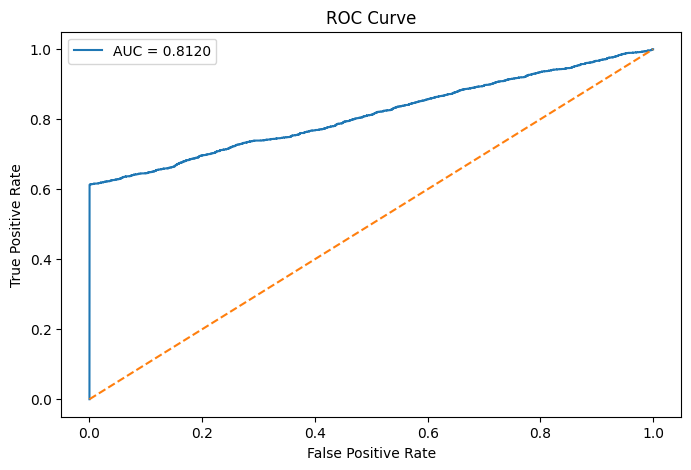

In [16]:
# 7. Evaluate Model
def evaluate_model(model, X_test, y_test):
    """Evaluates the model and prints metrics."""

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred))

    print("\n--- Confusion Matrix ---")
    print(confusion_matrix(y_test, y_pred))

    print("\n--- AUC Score ---")
    print(f"AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_proba):.4f}")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

evaluate_model(xgb_model, X_test, y_test)

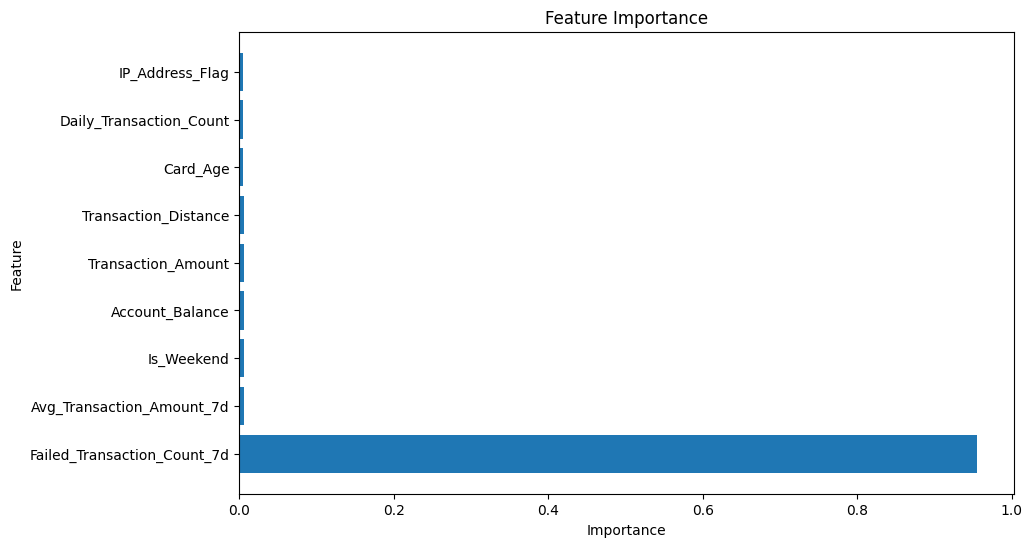

In [17]:
# 8. Feature Importance (Optional)
def plot_feature_importance(model, features):
    """Plots feature importance."""

    importances = model.feature_importances_
    feature_importance = pd.DataFrame({'Feature': features, 'Importance': importances})
    feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'])
    plt.title('Feature Importance')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

if features:  # Only plot if there are features to plot
    plot_feature_importance(xgb_model, features)
else:
    print("Error: Required columns not found in the dataset. Please check column names and adjust the code accordingly.")